# Pandas

![Pandas](https://i.natgeofe.com/n/992e3500-31cc-4b2c-b590-98321b274951/panda-cubs-group.jpg "Group of baby pandas" )


# Pandas Data Frames

In [137]:
import pandas as pd


## Building a data frame

In [138]:
# We can build a data frame using a dictionary
my_dict = {'dogs' : [1,0,4,3,2],
           'cats' : [3,2,0,1,1]}
my_dict


{'dogs': [1, 0, 4, 3, 2], 'cats': [3, 2, 0, 1, 1]}

In [139]:
animals = pd.DataFrame(my_dict)
display(animals)

,dogs,cats
0,1,3
1,0,2
2,4,0
3,3,1
4,2,1


In [140]:
type(animals)

pandas.core.frame.DataFrame

In [141]:
animals?

In [142]:
# fetch second row
animals.iloc[1]

,1
dogs,0
cats,2


In [143]:
animals.loc[1]

,1
dogs,0
cats,2


In [144]:
type(animals.iloc[1])

pandas.core.series.Series

In [145]:
(
  animals
.iloc[2]
.iloc[0]
 )

np.int64(4)

In [146]:
animals

,dogs,cats
0,1,3
1,0,2
2,4,0
3,3,1
4,2,1


In [147]:
# Change the index
animals = pd.DataFrame(my_dict, index = ['Joe', 'Mary', 'Roger', 'David', 'Mikey'])
display(animals)

,dogs,cats
Joe,1,3
Mary,0,2
Roger,4,0
David,3,1
Mikey,2,1


In [148]:
animals.iloc[1]

,Mary
dogs,0
cats,2


In [149]:
animals.loc["Mikey"]

,Mikey
dogs,2
cats,1


In [150]:
animals.iloc[0]


,Joe
dogs,1
cats,3


### Your Turn
Create a data frame that looks like the table below. Name this data frame `movies`. Use the `Movie` column as your index.

Movie | Lead Actor | Times Watched
------|------------|--------------
Titanic|Leo DiCaprio|3.0
Die Hard|Bruce Willis|5.0
Back to the Future | Michael J. Fox | 15.0
Forrest Gump | Tom Hanks | NaN

Note: to add a `NaN` to your dataframe, you will need to do the following:
1. Run `import numpy as np`
2. Use `np.nan` in your dataframe.

In [151]:
import numpy as np


In [152]:
movies_dict = {
  'Lead Actor': ['Leo DiCaprio', 'Bruce Willis', 'Michael J. Fox', 'Tom Hanks'] ,
  'Times Watched': [3, 5, 15, np.nan]
}
movies_dict


{'Lead Actor': ['Leo DiCaprio', 'Bruce Willis', 'Michael J. Fox', 'Tom Hanks'],
 'Times Watched': [3, 5, 15, nan]}

In [153]:
index_list = ['Titanic', 'Die Hard', 'Back to the Future', 'Forrest Gump']
index_list


['Titanic', 'Die Hard', 'Back to the Future', 'Forrest Gump']

In [154]:
movies = pd.DataFrame( movies_dict, index = index_list)
movies


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [155]:
# Solution
movies_str = '''
Movie	Lead Actor	Times Watched
Titanic	Leo DiCaprio	3
Die Hard	Bruce Willis	5
Back to the Future	Michael J. Fox	15
Forrest Gump	Tom Hanks	-2
'''
movies_str


'\nMovie\tLead Actor\tTimes Watched\nTitanic\tLeo DiCaprio\t3\nDie Hard\tBruce Willis\t5\nBack to the Future\tMichael J. Fox\t15\nForrest Gump\tTom Hanks\t-2\n'

In [156]:
movies_str.strip().split("\n")

['Movie\tLead Actor\tTimes Watched',
 'Titanic\tLeo DiCaprio\t3',
 'Die Hard\tBruce Willis\t5',
 'Back to the Future\tMichael J. Fox\t15',
 'Forrest Gump\tTom Hanks\t-2']

In [157]:
movies_lol = [ x.split("\t") for x in movies_str.strip().split("\n") ]
movies_lol


[['Movie', 'Lead Actor', 'Times Watched'],
 ['Titanic', 'Leo DiCaprio', '3'],
 ['Die Hard', 'Bruce Willis', '5'],
 ['Back to the Future', 'Michael J. Fox', '15'],
 ['Forrest Gump', 'Tom Hanks', '-2']]

In [158]:
movies_list = []
actor_list = []
times_list = []

for rows in movies_lol:
  movies_list.append(rows[0])
  actor_list.append(rows[1])
  times_list.append(rows[2])

times_list[1:] = [ int(x) for x in times_list[1:]]
times_list[-1] = np.nan

movies_list, actor_list, times_list


(['Movie', 'Titanic', 'Die Hard', 'Back to the Future', 'Forrest Gump'],
 ['Lead Actor', 'Leo DiCaprio', 'Bruce Willis', 'Michael J. Fox', 'Tom Hanks'],
 ['Times Watched', 3, 5, 15, nan])

In [159]:
movies_dict={movies_list[0] : movies_list[1:]}
actor_dict={actor_list[0] : actor_list[1:]}
times_dict={times_list[0] : times_list[1:]}

movies_dict, actor_dict, times_dict


({'Movie': ['Titanic', 'Die Hard', 'Back to the Future', 'Forrest Gump']},
 {'Lead Actor': ['Leo DiCaprio',
   'Bruce Willis',
   'Michael J. Fox',
   'Tom Hanks']},
 {'Times Watched': [3, 5, 15, nan]})

In [160]:
movies_dict.values()

dict_values([['Titanic', 'Die Hard', 'Back to the Future', 'Forrest Gump']])

In [161]:
list(movies_dict.values())[0]


['Titanic', 'Die Hard', 'Back to the Future', 'Forrest Gump']

In [162]:
index_list = list(movies_dict.values())[0]
index_list


['Titanic', 'Die Hard', 'Back to the Future', 'Forrest Gump']

In [163]:
{ **actor_dict, **times_dict }


{'Lead Actor': ['Leo DiCaprio', 'Bruce Willis', 'Michael J. Fox', 'Tom Hanks'],
 'Times Watched': [3, 5, 15, nan]}

In [164]:
movies = pd.DataFrame( { **actor_dict, **times_dict }, index = index_list )
movies


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


## Creating a data frame by reading in a CSV

In [165]:
# Read in CSV
url = "http://ddc-datascience.s3.amazonaws.com/Home_Data.csv"
url


'http://ddc-datascience.s3.amazonaws.com/Home_Data.csv'

In [166]:
home_data = pd.read_csv(url, usecols=range(9))


In [167]:
# Look at first 5 rows
home_data.head(5)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl


## Viewing/Understanding Data

In [168]:
# View the first 5 rows
home_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl


In [169]:
home_data.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl


In [170]:
# See the dimension of your data frame
home_data.shape

(1460, 9)

In [171]:
# See the information about each column in your data frame
home_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Id           1460 non-null   int64  
 1   MSSubClass   1460 non-null   int64  
 2   MSZoning     1460 non-null   object 
 3   LotFrontage  1201 non-null   float64
 4   LotArea      1460 non-null   int64  
 5   Street       1460 non-null   object 
 6   Alley        91 non-null     object 
 7   LotShape     1460 non-null   object 
 8   LandContour  1460 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 102.8+ KB


In [172]:
# Get summary statistics about your data frame
home_data.describe(include = "all" )


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460
unique,NaN,NaN,5,NaN,NaN,2,2,4,4
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN
25%,365.750000,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN
50%,730.500000,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN
75%,1095.250000,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN


In [173]:
# See the names of the columns
home_data.columns


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour'],
      dtype='object')

In [174]:
home_data.columns.to_list()

['Id',
 'MSSubClass',
 'MSZoning',
 'LotFrontage',
 'LotArea',
 'Street',
 'Alley',
 'LotShape',
 'LandContour']

### Your Turn
1. Use the `info()` and `describe()` methods on `movies` data frame.
2. Find another method that can be used on dataframes. Look at the help documentation for that method. Write a brief description of what that method does.

In [175]:
movies


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [176]:
# Solution
movies.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, Titanic to Forrest Gump
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Lead Actor     4 non-null      object 
 1   Times Watched  3 non-null      float64
dtypes: float64(1), object(1)
memory usage: 268.0+ bytes


In [177]:
# Solution
movies.describe(
  include="all"
)


,Lead Actor,Times Watched
count,4,3.000000
unique,4,NaN
top,Leo DiCaprio,NaN
freq,1,NaN
mean,NaN,7.666667
std,NaN,6.429101
min,NaN,3.000000
25%,NaN,4.000000
50%,NaN,5.000000
75%,NaN,10.000000


In [178]:
# Solution
help(movies.transpose)
# Transpose index and columns.


Help on method transpose in module pandas.core.frame:

transpose(*args, copy: 'bool' = False) -> 'DataFrame' method of pandas.core.frame.DataFrame instance
    Transpose index and columns.

    Reflect the DataFrame over its main diagonal by writing rows as columns
    and vice-versa. The property :attr:`.T` is an accessor to the method
    :meth:`transpose`.

    Parameters
    ----------
    *args : tuple, optional
        Accepted for compatibility with NumPy.
    copy : bool, default False
        Whether to copy the data after transposing, even for DataFrames
        with a single dtype.

        Note that a copy is always required for mixed dtype DataFrames,
        or for DataFrames with any extension types.

        .. note::
            The `copy` keyword will change behavior in pandas 3.0.
            `Copy-on-Write
            <https://pandas.pydata.org/docs/dev/user_guide/copy_on_write.html>`__
            will be enabled by default, which means that all methods with a
    

In [179]:
movies.transpose()


,Titanic,Die Hard,Back to the Future,Forrest Gump
Lead Actor,Leo DiCaprio,Bruce Willis,Michael J. Fox,Tom Hanks
Times Watched,3.0,5.0,15.0,NaN


## Cleaning Data

In [180]:
home_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl


In [181]:
# Dealing with Missing Values
home_data.isnull().head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour
0,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,True,False,False


In [182]:
home_data.isnull().sum()


,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
Street,0
Alley,1369
LotShape,0
LandContour,0


In [183]:
# Let's drop the columns with NaNs.
# First, we need to create a copy of our data frame
home_data_clean = home_data.copy()
home_data_clean.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl


In [184]:
# axis = 1 tells the function to drop a column instead of a row
# in place tells the function to alter home_data_clean instead of returning a new data frame
# home_data_clean.dropna(axis = "columns", inplace=True)
home_data_clean.dropna(axis = 1, inplace=True)
home_data_clean.head()

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour
0,1,60,RL,8450,Pave,Reg,Lvl
1,2,20,RL,9600,Pave,Reg,Lvl
2,3,60,RL,11250,Pave,IR1,Lvl
3,4,70,RL,9550,Pave,IR1,Lvl
4,5,60,RL,14260,Pave,IR1,Lvl


In [185]:
home_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl


### Your Turn
Make a copy of your `movies` data frame. Save it as `movies_clean`.
Drop the **row** that contains a NaN.

In [186]:
movies


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [187]:
# Solution
movies_clean = movies.copy()
movies_clean


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [188]:
# Solution
movies_clean.dropna(
  axis = "rows",
  inplace = True,
)


In [189]:
movies_clean


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0


## Imputation
Let's say we didn't want to just drop the LotFrontage column as it only had 259 NaNs.

In [190]:
# Make a copy
home_data_impute = home_data.copy()
home_data_impute.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl


In [191]:
# Remove only the Alley column
# home_data_impute.drop(labels = ['Alley'], axis = "columns", inplace = True)
home_data_impute.drop(labels = ['Alley'], axis = 1, inplace = True)
home_data_impute.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour
0,1,60,RL,65.0,8450,Pave,Reg,Lvl
1,2,20,RL,80.0,9600,Pave,Reg,Lvl
2,3,60,RL,68.0,11250,Pave,IR1,Lvl
3,4,70,RL,60.0,9550,Pave,IR1,Lvl
4,5,60,RL,84.0,14260,Pave,IR1,Lvl


In [192]:
# Check to see our NaNs
home_data_impute.isnull().sum().sort_values()

,0
Id,0
MSSubClass,0
MSZoning,0
LotArea,0
LotShape,0
Street,0
LandContour,0
LotFrontage,259


In [193]:
home_data_impute['LotFrontage']

,LotFrontage
0,65.0
1,80.0
2,68.0
3,60.0
4,84.0
...,...
1455,62.0
1456,85.0
1457,66.0
1458,68.0


In [194]:
# Replace the NaNs in LotFrontage with the mean lot frontage amount
lot_frontage_mean = home_data_impute['LotFrontage'].mean()
lot_frontage_mean

np.float64(70.04995836802665)

In [195]:
home_data_impute.fillna(lot_frontage_mean, inplace = True)
home_data_impute.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
LotShape,0
LandContour,0


In [196]:
home_data_impute.describe( include = "all")

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour
count,1460.000000,1460.000000,1460,1460.000000,1460.000000,1460,1460,1460
unique,NaN,NaN,5,NaN,NaN,2,4,4
top,NaN,NaN,RL,NaN,NaN,Pave,Reg,Lvl
freq,NaN,NaN,1151,NaN,NaN,1454,925,1311
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN
std,421.610009,42.300571,NaN,22.024023,9981.264932,NaN,NaN,NaN
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN
25%,365.750000,20.000000,NaN,60.000000,7553.500000,NaN,NaN,NaN
50%,730.500000,50.000000,NaN,70.049958,9478.500000,NaN,NaN,NaN
75%,1095.250000,70.000000,NaN,79.000000,11601.500000,NaN,NaN,NaN


### Your Turn
1. Make another copy of your original `movies` data frame and save it as `movies_impute`.
2. In `movies_impute`, replace the NaN with a 0.

In [197]:
movies


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [198]:
# Solution 1
movies_impute = movies.copy()
movies_impute


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [199]:
# Solution 2
movies_impute.fillna(
  value = 0,
  inplace = True,
)
movies_impute


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,0.0


## Indexing by Column

In [200]:
# We can index a column using square brackets and the column name
street_col = home_data_impute['Street']
street_col.head()

,Street
0,Pave
1,Pave
2,Pave
3,Pave
4,Pave


In [201]:
type(street_col)

pandas.core.series.Series

In [202]:
# We can index multiple columns using a list of column names
multiple_cols = home_data_impute[['Street', 'LotShape']]
multiple_cols.head()

,Street,LotShape
0,Pave,Reg
1,Pave,Reg
2,Pave,IR1
3,Pave,IR1
4,Pave,IR1


In [203]:
type(multiple_cols)

pandas.core.frame.DataFrame

In [204]:
street_col = home_data_impute[['Street']]
street_col.head()

,Street
0,Pave
1,Pave
2,Pave
3,Pave
4,Pave


In [205]:
type(street_col)

pandas.core.frame.DataFrame

### Your Turn
1. Index the `Lead Actor` column of your `movies_impute` data frame.
2. Save it to a variable called `actors`.
3. Print out `actors`.
4. Display the data type of `actors`.

In [206]:
movies_impute


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,0.0


In [207]:
# Solution 1
movies_impute["Lead Actor"]


,Lead Actor
Titanic,Leo DiCaprio
Die Hard,Bruce Willis
Back to the Future,Michael J. Fox
Forrest Gump,Tom Hanks


In [208]:
# Solution 2
actors = movies_impute["Lead Actor"]
actors


,Lead Actor
Titanic,Leo DiCaprio
Die Hard,Bruce Willis
Back to the Future,Michael J. Fox
Forrest Gump,Tom Hanks


In [209]:
# Solution 3
print(actors)


Titanic                 Leo DiCaprio
Die Hard                Bruce Willis
Back to the Future    Michael J. Fox
Forrest Gump               Tom Hanks
Name: Lead Actor, dtype: object


In [210]:
# Solution 4
type(actors)


pandas.core.series.Series

## Indexing by Row
We can index rows in two ways:

- .loc - locates by name
- .iloc- locates by numerical index

In [211]:
# Let's take a look at the animals data frame we created earlier
animals

,dogs,cats
Joe,1,3
Mary,0,2
Roger,4,0
David,3,1
Mikey,2,1


In [212]:
# Index using loc
animals.loc['Roger']

,Roger
dogs,4
cats,0


In [213]:
# Index using iloc
animals.iloc[2]

,Roger
dogs,4
cats,0


In [214]:
# We can also slice!
animals.loc['Roger':'Mikey'] # Note - the stop point in .loc is inclusive

,dogs,cats
Roger,4,0
David,3,1
Mikey,2,1


In [215]:
animals.iloc[2:4] # The stop point in .iloc is not inclusive

,dogs,cats
Roger,4,0
David,3,1


In [216]:
animals.iloc[2:4]['dogs']

,dogs
Roger,4
David,3


In [217]:
( animals.iloc[2:4] )['dogs']

,dogs
Roger,4
David,3


In [218]:
( ( animals ).iloc[2:4] )['dogs']

,dogs
Roger,4
David,3


In [219]:
animals['dogs'].iloc[2:4]

,dogs
Roger,4
David,3


In [220]:
pd.DataFrame(animals['dogs'].iloc[2:4])

,dogs
Roger,4
David,3


In [221]:
animals[['dogs']].iloc[2:4]

,dogs
Roger,4
David,3


### Your Turn
1. Index the row for `Back to the Future` from the `movies` data frame using .loc and iloc.
2. Use a slice to index the rows for `Back to the Future` and `Forrest Gump`.

In [222]:
movies


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [223]:
# Solution 1 - .loc
movies.loc["Back to the Future"]


,Back to the Future
Lead Actor,Michael J. Fox
Times Watched,15.0


In [224]:
# Solution 1 - .iloc
movies.iloc[2]


,Back to the Future
Lead Actor,Michael J. Fox
Times Watched,15.0


In [225]:
# Solution 2
movies.loc["Back to the Future":"Forrest Gump"]


,Lead Actor,Times Watched
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [226]:
movies.iloc[-2:]

,Lead Actor,Times Watched
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


In [227]:
movies.iloc[2:]

,Lead Actor,Times Watched
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,NaN


# ====== Start Here =====


## Conditional Selections

In [228]:
animals

,dogs,cats
Joe,1,3
Mary,0,2
Roger,4,0
David,3,1
Mikey,2,1


In [229]:
# We can use conditional statements to return booleans
animals['dogs'] == 4

,dogs
Joe,False
Mary,False
Roger,True
David,False
Mikey,False


In [230]:
# We can then use those booleans to index our data frame
filter = ( animals['dogs'] == 4 )
animals[ filter ]


,dogs,cats
Roger,4,0


In [231]:
# Another example
animals[ animals['cats'] > 1 ]

,dogs,cats
Joe,1,3
Mary,0,2


In [232]:
# A third example!
# Two things to note - we have to put parenthesis around each conditional statement
# and we have to use the '&' symbol instead of the word 'and'
animals[(animals['cats'] > 1) & (animals['dogs'] < 1)]


,dogs,cats
Mary,0,2


In [233]:
filter1 = (animals['cats'] > 1)
filter1
filter2 = (animals['dogs'] < 1)
filter2
filter3 = filter1 & filter2
filter3

animals[filter3]

,dogs,cats
Mary,0,2


In [234]:
animals[ filter1 + filter2]

,dogs,cats
Joe,1,3
Mary,0,2


In [235]:
pd.concat([filter1, filter2, filter1 & filter2, filter1 + filter2 ], axis=1)

,cats,dogs,0,1
Joe,True,False,False,True
Mary,True,True,True,True
Roger,False,False,False,False
David,False,False,False,False
Mikey,False,False,False,False


### Your Turn
Use a conditional statement to return the following from your `movies_impute` data frame:
1. Movies with Bruce Willis as the lead actor
2. Movies that have been watched more than 4 times

In [236]:
movies_impute


,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,0.0


In [237]:
# Solution 1
filter1 = movies_impute["Lead Actor"]=="Bruce Willis"
filter1


,Lead Actor
Titanic,False
Die Hard,True
Back to the Future,False
Forrest Gump,False


In [238]:
# Solution 2
movies_impute [filter1]

,Lead Actor,Times Watched
Die Hard,Bruce Willis,5.0


## Adding a Column

In [255]:
animals


,dogs,cats,chickens,ducks,Total,all
Joe,1,3,1,20,25,50
Mary,0,2,0,20,22,44
Roger,4,0,0,20,24,48
David,3,1,4,20,28,56
Mikey,2,1,5,20,28,56
Nevin,1,0,0,4,5,10


In [240]:
# We can easily add a column to our data frame
animals['chickens'] = [1,0,0,4,5]
animals

,dogs,cats,chickens
Joe,1,3,1
Mary,0,2,0
Roger,4,0,0
David,3,1,4
Mikey,2,1,5


In [241]:
# Add a single value to all rows, i.e. broadcasting
animals['ducks'] = 20
animals

,dogs,cats,chickens,ducks
Joe,1,3,1,20
Mary,0,2,0,20
Roger,4,0,0,20
David,3,1,4,20
Mikey,2,1,5,20


In [256]:
# Calculations
animals["Total"] = animals["dogs"] + animals["cats"] + animals["chickens"] + animals["ducks"]
animals

,dogs,cats,chickens,ducks,Total,all
Joe,1,3,1,20,25,50
Mary,0,2,0,20,22,44
Roger,4,0,0,20,24,48
David,3,1,4,20,28,56
Mikey,2,1,5,20,28,56
Nevin,1,0,0,4,5,10


In [257]:
animals["all"] = animals.sum(axis = 1)
animals

,dogs,cats,chickens,ducks,Total,all
Joe,1,3,1,20,25,100
Mary,0,2,0,20,22,88
Roger,4,0,0,20,24,96
David,3,1,4,20,28,112
Mikey,2,1,5,20,28,112
Nevin,1,0,0,4,5,20


In [258]:
animals.sum(axis = "columns")

,0
Joe,150
Mary,132
Roger,144
David,168
Mikey,168
Nevin,30


## Adding a Row

In [259]:
# Similarly, we can add a row to our data frame
animals.loc['Nevin'] = [1,0,0,4,5,10]
animals

,dogs,cats,chickens,ducks,Total,all
Joe,1,3,1,20,25,100
Mary,0,2,0,20,22,88
Roger,4,0,0,20,24,96
David,3,1,4,20,28,112
Mikey,2,1,5,20,28,112
Nevin,1,0,0,4,5,10


### Your Turn
1. Add a column named `Rating` to your `movies_impute` data frame that gives your rating of the movie on a scale from 1-10 (where 10 is the best).
2. Add a row to your `movies_impute` data frame with the information for another movie.

In [246]:
movies_impute
movies_impute

,Lead Actor,Times Watched
Titanic,Leo DiCaprio,3.0
Die Hard,Bruce Willis,5.0
Back to the Future,Michael J. Fox,15.0
Forrest Gump,Tom Hanks,0.0


In [261]:
# Solution 1
movies_impute['Rating']= [ 6,7,8,9]
movies_impute

,Lead Actor,Times Watched,Rating
Titanic,Leo DiCaprio,3.0,6
Die Hard,Bruce Willis,5.0,7
Back to the Future,Michael J. Fox,15.0,8
Forrest Gump,Tom Hanks,0.0,9


In [268]:
# Solution 2
movies_impute.loc["irobot"] = ["will smith", 2,5]
movies_impute

,Lead Actor,Times Watched,Rating
Titanic,Leo DiCaprio,3.0,6
Die Hard,Bruce Willis,5.0,7
Back to the Future,Michael J. Fox,15.0,8
Forrest Gump,Tom Hanks,0.0,9
irobot,will smith,2.0,5


## A Quick Intro to Plotting Using Pandas

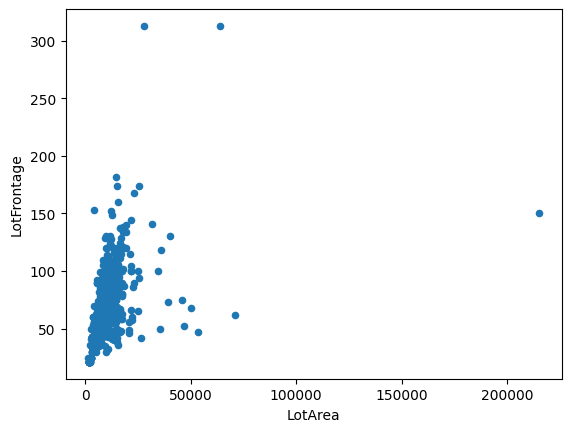

In [249]:
home_data.plot(
  kind = 'scatter',
     x = 'LotArea',
     y = 'LotFrontage',
) ;


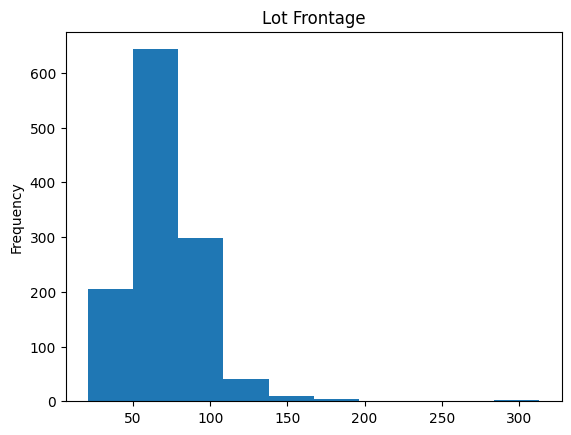

In [250]:
home_data['LotFrontage'].plot(kind = 'hist', title = 'Lot Frontage') ;

In [269]:
# Note positive skew, i.e mean > median ( 50% )
home_data[['LotFrontage']].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
LotFrontage,1201.0,70.049958,24.284752,21.0,59.0,69.0,80.0,313.0


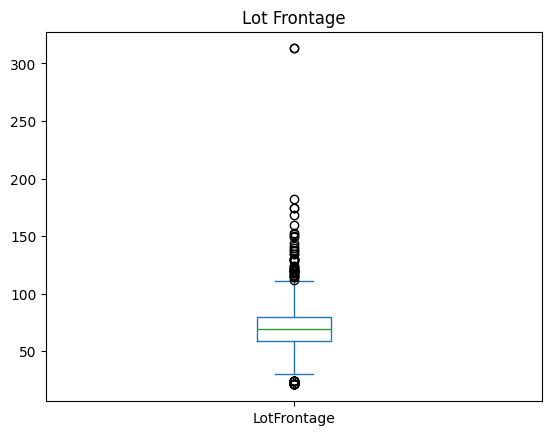

In [270]:
home_data['LotFrontage'].plot(kind = 'box', title = 'Lot Frontage') ;

### Your Turn
Create a scatter plot of your `Rating` column versus your `Times Watched` column from you `movies_impute` data frame.

In [281]:
movies_impute


,Lead Actor,Times Watched,Rating
Titanic,Leo DiCaprio,3.0,6
Die Hard,Bruce Willis,5.0,7
Back to the Future,Michael J. Fox,15.0,8
Forrest Gump,Tom Hanks,0.0,9
irobot,will smith,2.0,5


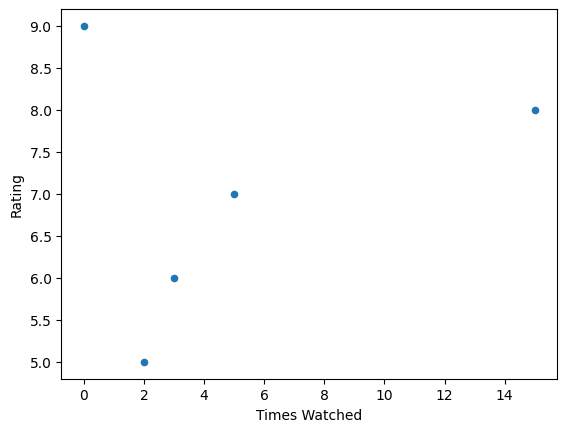

In [284]:
# Solution
movies_impute.plot(
  kind = 'scatter',
     x = 'Times Watched',
     y = 'Rating',
) ;